# Primary Data Analysis with SasView (scripts)

This notebook reproduces the **Primary Data Analysis** tutorial from
[sastutorials.org](https://sastutorials.org/PrimaryDataAnalysis/PrimaryDataAnalysis.html)
using the SasView Python stack:

* **`sasdata`** &mdash; loading the experimental scattering curves
* **`sasmodels`** + **`bumps`** &mdash; the Guinier model fit
* **`matplotlib`** / **`numpy`** &mdash; plotting and manual cross-checks

*Original tutorial by Andreas Haahr Larsen, Martin Cramer Pedersen and Jeppe Breum Jacobsen.*

**What we cover**

1. Loading SAXS/SANS data with `sasdata`
2. **Guinier analysis** &rarr; radius of gyration $R_g$ and forward scattering $I(0)$
3. **Kratky plots** &rarr; assessing foldedness / flexibility
4. Three challenges (RNase A, MAP2, pH-dependent discoidal particles)

> The **P(r) / indirect Fourier transform** part of the original tutorial is
> covered by another tutorial


## Setup

Import the SasView stack. If any package is missing, install with:

```bash
pip install sasdata sasmodels bumps matplotlib numpy ipywidgets
```


In [2]:
import io
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

from sasdata.dataloader.loader import Loader
from sasmodels.core import load_model
from sasmodels.bumps_model import Model, Experiment
from sasmodels.data import Data1D as SasData1D
from bumps.names import FitProblem
from bumps.fitters import fit

DATA = "data"   # folder containing the .dat files
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["figure.dpi"] = 110


## 1. Loading data with `sasdata`

`sasdata`'s `Loader` auto-detects the file format and returns a `Data1D`
object with `.x` ($q$), `.y` ($I$) and `.dy` (uncertainty on $I$).

Our reference dataset is **lysozyme** (SASBDB entry `SASDMF2`).


In [3]:
loader = Loader()

def load(name):
    '''Load a 1D curve with sasdata and return (q, I, dI).'''
    data = loader.load(f"{DATA}/{name}")[0]
    q  = np.asarray(data.x, dtype=float)
    I  = np.asarray(data.y, dtype=float)
    dI = np.asarray(data.dy, dtype=float) if data.dy is not None else np.sqrt(np.abs(I))
    return q, I, dI

q, I, dI = load("SASDMF2.dat")
print(f"Loaded lysozyme: {len(q)} points")
print(f"q range: {q.min():.4f} - {q.max():.4f} 1/A")


Loaded lysozyme: 222 points
q range: 0.0080 - 1.7200 1/A


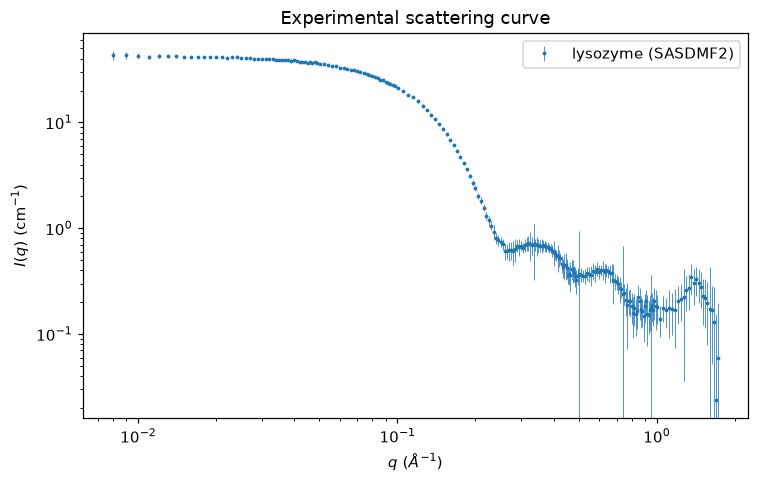

In [4]:
fig, ax = plt.subplots()
ax.errorbar(q, I, yerr=dI, fmt=".", ms=3, lw=0.5, color="C0", label="lysozyme (SASDMF2)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$q\ (\AA^{-1})$"); ax.set_ylabel(r"$I(q)\ (\mathrm{cm}^{-1})$")
ax.set_title("Experimental scattering curve"); ax.legend()
plt.tight_layout(); plt.show()


## 2. Guinier analysis

At low $q$ the scattering of a monodisperse, dilute sample follows the
**Guinier approximation**

$$I(q) \approx I(0)\,\exp\!\left(-\tfrac{1}{3}q^2 R_g^2\right)
\qquad\Longleftrightarrow\qquad
\ln I(q) = \ln I(0) - \tfrac{R_g^2}{3}\,q^2 .$$

So a plot of $\ln I$ vs $q^2$ is a straight line whose **slope** gives $R_g$
and whose **intercept** gives $I(0)$.

The approximation is only valid in the low-$q$ *Guinier region*:

* $qR_g \le 1.3$ for globular particles
* $qR_g \le 1.0$ for elongated particles

Below, use the **$q_{\min}$ / $q_{\max}$ sliders** to choose the fitting
window. Watch $qR_g$ and the residuals: widen or narrow the range until the
fit stays linear and $qR_g$ respects the limits above.


In [5]:
def guinier_fit(q, I, dI, qmin, qmax, min_pts=6):
    '''Fit ln(I) vs q^2 by weighted linear least squares over [qmin, qmax].

    Returns (Rg, I0, mask, sigma_Rg, sigma_I0).'''
    pos = I > 0
    mask = (q >= qmin) & (q <= qmax) & pos
    if mask.sum() < min_pts:
        raise ValueError(
            f"Need at least {min_pts} positive points in "
            f"[{qmin:.4f}, {qmax:.4f}], got {mask.sum()}")
    x = q[mask] ** 2
    y = np.log(I[mask])
    w = I[mask] / dI[mask]                      # weight ~ 1/sigma(ln I)
    p, cov = np.polyfit(x, y, 1, w=w, cov=True)
    if p[0] >= 0:
        raise ValueError("Fit slope is non-negative; Guinier region invalid")
    rg = np.sqrt(-3.0 * p[0])
    I0 = np.exp(p[1])
    sigma_rg = (np.sqrt(cov[0, 0]) * 3.0 / (2.0 * rg)
                if cov[0, 0] > 0 else np.nan)
    sigma_I0 = I0 * np.sqrt(cov[1, 1])
    return rg, I0, mask, sigma_rg, sigma_I0


def guinier_figure(q, I, dI, mask, rg, I0, title=""):
    '''Build a Guinier plot figure (caller must close it).

    Labels intentionally avoid matplotlib mathtext ($...$), which is
    unreliable inside ipywidgets Output contexts in some Jupyter setups.
    '''
    x = q**2
    lnI = np.log(np.where(I > 0, I, np.nan))
    line = np.log(I0) - (rg**2 / 3.0) * x
    fig, (ax1, ax2) = plt.subplots(
        2, 1, sharex=True, gridspec_kw={"height_ratios": [3, 1]},
        constrained_layout=True)
    ax1.plot(x, lnI, ".", ms=4, color="0.6", label="all data")
    ax1.plot(x[mask], lnI[mask], "o", ms=4, color="C0",
             label="Guinier region")
    xr = np.linspace(0, x[mask].max(), 50)
    ax1.plot(xr, np.log(I0) - (rg**2 / 3.0) * xr, "-", color="C3",
             label=f"fit: Rg={rg:.2f} Å, I0={I0:.1f}")
    ax1.set_ylabel("ln I(q)"); ax1.legend(); ax1.set_title(title)
    ax1.set_xlim(0, x[mask].max() * 1.6)

    resid = (lnI[mask] - line[mask]) * (I[mask] / dI[mask])
    ax2.plot(x[mask], resid, "o", ms=4, color="C0")
    ax2.axhline(0, color="C3", lw=1)
    ax2.set_xlabel("q² (Å⁻²)")
    ax2.set_ylabel("norm.\nresid.")
    return fig


def guinier_plot(q, I, dI, mask, rg, I0, title=""):
    '''Show a Guinier plot (non-interactive cells).'''
    fig = guinier_figure(q, I, dI, mask, rg, I0, title=title)
    plt.show()
    plt.close(fig)


def _fig_to_png(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110)
    plt.close(fig)
    buf.seek(0)
    return buf.read()


def interactive_guinier(q, I, dI, title="", qmin0=None, qmax0=None):
    '''Sliders for qmin/qmax; refits and replots the Guinier analysis.

    Returns a dict updated live with rg, I0, mask, s_rg, s_I0, qmin, qmax.
    '''
    q_pos = q[I > 0]
    q_lo, q_hi = float(q_pos.min()), float(q_pos.max())
    if qmin0 is None:
        qmin0 = q_lo
    if qmax0 is None:
        qmax0 = float(q_pos[min(len(q_pos) - 1, max(12, len(q_pos) // 8))])
    step = max((q_hi - q_lo) / 300, 1e-5)

    state = {}
    qmin_s = widgets.FloatSlider(
        value=qmin0, min=q_lo, max=q_hi, step=step,
        description="qmin", readout_format=".4f",
        continuous_update=False, style={"description_width": "40px"},
        layout=widgets.Layout(width="420px"))
    qmax_s = widgets.FloatSlider(
        value=qmax0, min=q_lo, max=q_hi, step=step,
        description="qmax", readout_format=".4f",
        continuous_update=False, style={"description_width": "40px"},
        layout=widgets.Layout(width="420px"))
    info = widgets.HTML(value="")
    image = widgets.Image(format="png", layout=widgets.Layout(width="770px"))

    def _update(_=None):
        qmin, qmax = float(qmin_s.value), float(qmax_s.value)
        if qmin >= qmax:
            info.value = "<b>Require qmin &lt; qmax</b>"
            return
        try:
            rg, I0, mask, s_rg, s_I0 = guinier_fit(q, I, dI, qmin, qmax)
        except ValueError as exc:
            info.value = f"<b>{exc}</b>"
            return
        state.update(rg=rg, I0=I0, mask=mask, s_rg=s_rg, s_I0=s_I0,
                     qmin=qmin, qmax=qmax)
        qRg = q[mask] * rg
        notes = ""
        if qRg[-1] > 1.3:
            notes = "<br><i>Note: qRg_max &gt; 1.3 (typical globular limit)</i>"
        elif qRg[-1] > 1.0:
            notes = ("<br><i>Note: qRg_max &gt; 1.0 "
                     "(elongated-particle limit)</i>")
        info.value = (
            "<pre style='margin:0'>Linear Guinier fit:\n"
            f"  Rg   = {rg:6.2f} +/- {s_rg:.2f} A\n"
            f"  I(0) = {I0:6.2f} +/- {s_I0:.2f} cm^-1\n"
            f"  Region: {mask.sum()} pts, "
            f"q = {qmin:.4f} - {qmax:.4f} 1/A, "
            f"qRg = {qRg[0]:.2f} - {qRg[-1]:.2f}</pre>{notes}"
        )
        fig = guinier_figure(q, I, dI, mask, rg, I0, title=title)
        image.value = _fig_to_png(fig)

    qmin_s.observe(_update, names="value")
    qmax_s.observe(_update, names="value")
    display(widgets.VBox([qmin_s, qmax_s, info, image]))
    _update()
    return state


# Lysozyme: adjust qmin/qmax until the Guinier region looks linear
# and qRg stays within the globular limit (~1.3).
lyso = interactive_guinier(q, I, dI, title="Lysozyme Guinier analysis",
                           qmin0=float(q[I > 0][0]), qmax0=0.09)


### The same fit with the SasView `guinier` model

The manual linear fit above is transparent, but SasView ships a proper
`guinier` model. We fit it (via `bumps`) to exactly the same $q$-region so the
two approaches can be cross-checked.


In [6]:
GUINIER = load_model("guinier")   # load once and reuse across fits

def sasview_guinier_fit(q, I, dI, mask, rg0, I0_0):
    '''Fit the sasmodels 'guinier' model over the selected region.'''
    sd = SasData1D(q[mask], I[mask]); sd.dy = dI[mask]
    model = Model(GUINIER, scale=I0_0, rg=rg0)
    model.rg.range(1, 500)
    model.scale.range(0, 1e9)
    problem = FitProblem(Experiment(data=sd, model=model))
    fit(problem, method="lm", verbose=False)
    return model.rg.value, model.scale.value

# Uses the q-region currently selected by the sliders above.
rg_lin, I0_lin, mask = lyso["rg"], lyso["I0"], lyso["mask"]
rg_sv, I0_sv = sasview_guinier_fit(q, I, dI, mask, rg_lin, I0_lin)
print(f"SasView guinier model (q = {lyso['qmin']:.4f} - {lyso['qmax']:.4f}):")
print(f"  Rg   = {rg_sv:6.2f} A")
print(f"  I(0) = {I0_sv:6.2f} cm^-1")
print(f"\nLysozyme reference Rg ~ 14-15 A -> consistent.")


SasView guinier model (q = 0.0080 - 0.0900):
  Rg   =  14.41 A
  I(0) =  42.56 cm^-1

Lysozyme reference Rg ~ 14-15 A -> consistent.


### Reading the interactive Guinier plot

The top panel shows $\ln I$ vs $q^2$ with the fitted line; the fitted region
is highlighted. The bottom panel shows normalised residuals &mdash; they should
scatter randomly around zero inside the Guinier region. Systematic curvature
at low $q$ would hint at aggregation or interparticle interference.

Move the sliders, then **re-run the SasView cell above** if you want the
model cross-check on the new window.


In [7]:
# Convenience aliases used by later cells (Kratky, challenges).
rg_lin, I0_lin, mask = lyso["rg"], lyso["I0"], lyso["mask"]
print(f"Current slider window: q = {lyso['qmin']:.4f} - {lyso['qmax']:.4f} 1/A")
print(f"  linear Rg = {rg_lin:.2f} A,  SasView Rg = {rg_sv:.2f} A")


Current slider window: q = 0.0080 - 0.0900 1/A
  linear Rg = 14.41 A,  SasView Rg = 14.41 A


## 3. Kratky plot

The **Kratky plot** &mdash; $q^2 I(q)$ vs $q$ &mdash; emphasises the mid-$q$ region
and reports on **compactness/flexibility**:

* a **folded, globular** particle gives a clear **bell-shaped peak** that
  decays back toward the baseline;
* an **unfolded / flexible / extended** chain gives a monotonically rising
  plateau at high $q$.

The **dimensionless (normalised) Kratky plot**, $(qR_g)^2 I(q)/I(0)$ vs $qR_g$,
lets curves from different particles be compared directly. For an ideal
globular particle the peak sits at $qR_g=\sqrt{3}\approx1.73$ with height
$3/e\approx1.10$ (the Guinier&ndash;Kratky reference point).


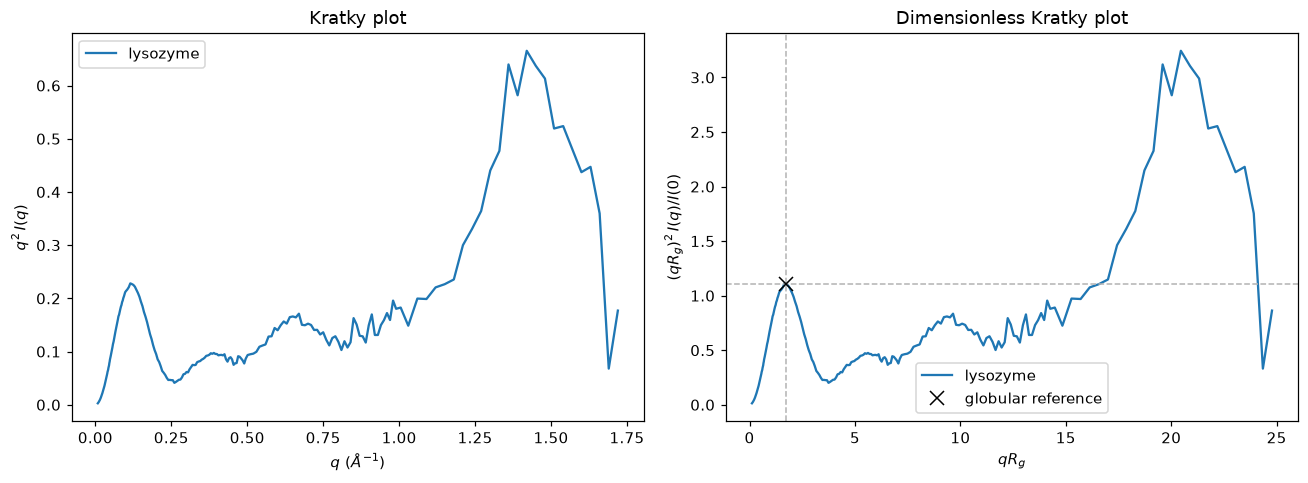

The peak near qRg ~ sqrt(3) confirms lysozyme is compact and folded.


In [8]:
def kratky(q, I, ax=None, label=None, **kw):
    ax = ax or plt.gca()
    ax.plot(q, q**2 * I, "-", label=label, **kw)
    ax.set_xlabel(r"$q\ (\AA^{-1})$"); ax.set_ylabel(r"$q^2\,I(q)$")
    return ax

def dimensionless_kratky(q, I, rg, I0, ax=None, label=None, **kw):
    ax = ax or plt.gca()
    ax.plot(q*rg, (q*rg)**2 * I / I0, "-", label=label, **kw)
    ax.set_xlabel(r"$qR_g$"); ax.set_ylabel(r"$(qR_g)^2\,I(q)/I(0)$")
    return ax

fig, (axa, axb) = plt.subplots(1, 2, figsize=(12, 4.5))
kratky(q, I, ax=axa, label="lysozyme", color="C0")
axa.set_title("Kratky plot"); axa.legend()

dimensionless_kratky(q, I, rg_sv, I0_sv, ax=axb, label="lysozyme", color="C0")
axb.axvline(np.sqrt(3), color="0.7", ls="--", lw=1)
axb.axhline(3/np.e, color="0.7", ls="--", lw=1)
axb.plot(np.sqrt(3), 3/np.e, "kx", ms=9, label="globular reference")
axb.set_title("Dimensionless Kratky plot"); axb.legend()
plt.tight_layout(); plt.show()

print("The peak near qRg ~ sqrt(3) confirms lysozyme is compact and folded.")


## Challenges

Apply the same Guinier / Kratky tools to three new datasets.
For each challenge, **write down your own conclusions** before moving on —
the notebook will not tell you the “right” answer.


### Challenge 1 &mdash; RNase A (SANS in D$_2$O)

Load `RNAseA.dat` and determine $R_g$ (and $I(0)$) from a Guinier analysis.

**Questions to consider**

* Which $q_{\min}$–$q_{\max}$ window gives a linear Guinier region with
  trustworthy residuals?
* What $R_g$ do you obtain, and is $qR_g$ within the usual limit for a
  compact particle?
* How does your $R_g$ compare with lysozyme from earlier in the notebook?


In [9]:
q1, I1, dI1 = load("RNAseA.dat")
rnase = interactive_guinier(q1, I1, dI1, title="Challenge 1: RNase A",
                            qmin0=float(q1[I1 > 0][0]), qmax0=0.10)

# Optional: cross-check the current slider window with the SasView guinier model
rg1, I01, mask1 = rnase["rg"], rnase["I0"], rnase["mask"]
rg1_sv, I01_sv = sasview_guinier_fit(q1, I1, dI1, mask1, rg1, I01)
print(f"SasView cross-check: Rg = {rg1_sv:.2f} A,  I(0) = {I01_sv:.2f}")


SasView cross-check: Rg = 13.64 A,  I(0) = 1.00


### Challenge 2 &mdash; MAP2 (folding state)

Analyse `map2.dat`. Estimate $R_g$ from a Guinier fit, then compare its
**Kratky** (and dimensionless Kratky) plot with lysozyme.

**Questions to consider**

* Is the Guinier region well behaved? Which $qR_g$ cutoff seems appropriate?
* Does the Kratky plot look like that of a compact, globular particle?
* What does that suggest about the conformational state of MAP2?


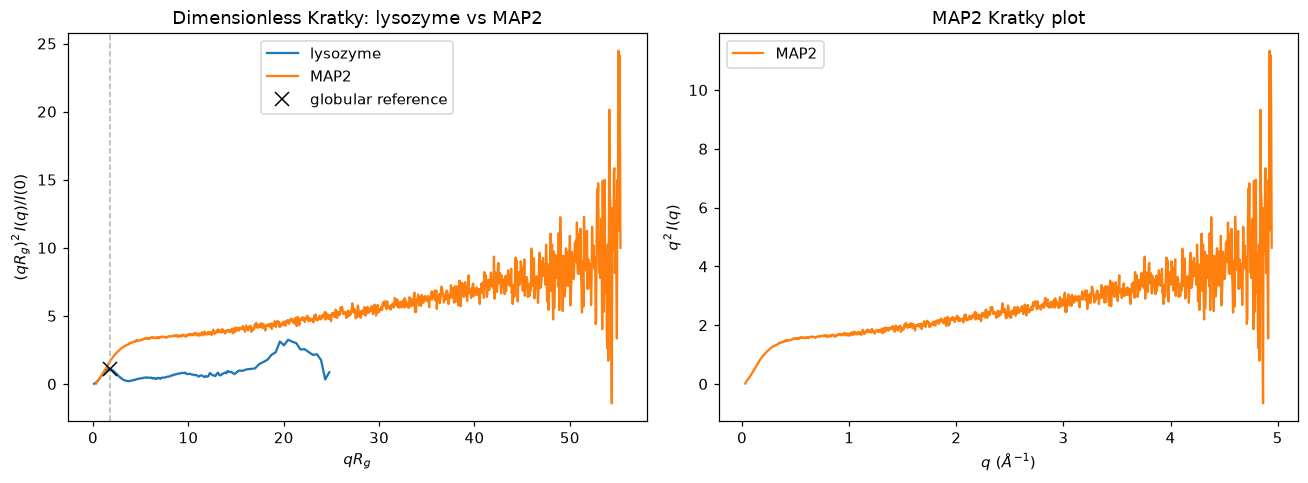

In [10]:
q2, I2, dI2 = load("map2.dat")
map2 = interactive_guinier(q2, I2, dI2, title="Challenge 2: MAP2",
                           qmin0=float(q2[I2 > 0][0]), qmax0=0.08)
rg2, I02 = map2["rg"], map2["I0"]

fig, (axa, axb) = plt.subplots(1, 2, figsize=(12, 4.5))
dimensionless_kratky(q, I, rg_sv, I0_sv, ax=axa,
                     label="lysozyme", color="C0")
dimensionless_kratky(q2, I2, rg2, I02, ax=axa, label="MAP2", color="C1")
axa.axvline(np.sqrt(3), color="0.7", ls="--", lw=1)
axa.plot(np.sqrt(3), 3 / np.e, "kx", ms=9, label="globular reference")
axa.set_title("Dimensionless Kratky: lysozyme vs MAP2"); axa.legend()

kratky(q2, I2, ax=axb, label="MAP2", color="C1")
axb.set_title("MAP2 Kratky plot"); axb.legend()
plt.tight_layout(); plt.show()


### Challenge 3 &mdash; pH-dependent discoidal particles

Compare simulated SAXS from discoidal particles at **neutral** and **low** pH
(`SAXS_neutral_pH.dat`, `SAXS_low_pH.dat`).

**Questions to consider**

* How do $R_g$ and $I(0)$ change between the two conditions?
* Do the low-$q$ shapes of the curves differ (upturn, suppression, …)?
* What physical picture is consistent with your observations
  (size change, aggregation, interparticle interactions, …)?


Neutral pH — choose a Guinier window:


Low pH — choose a Guinier window:


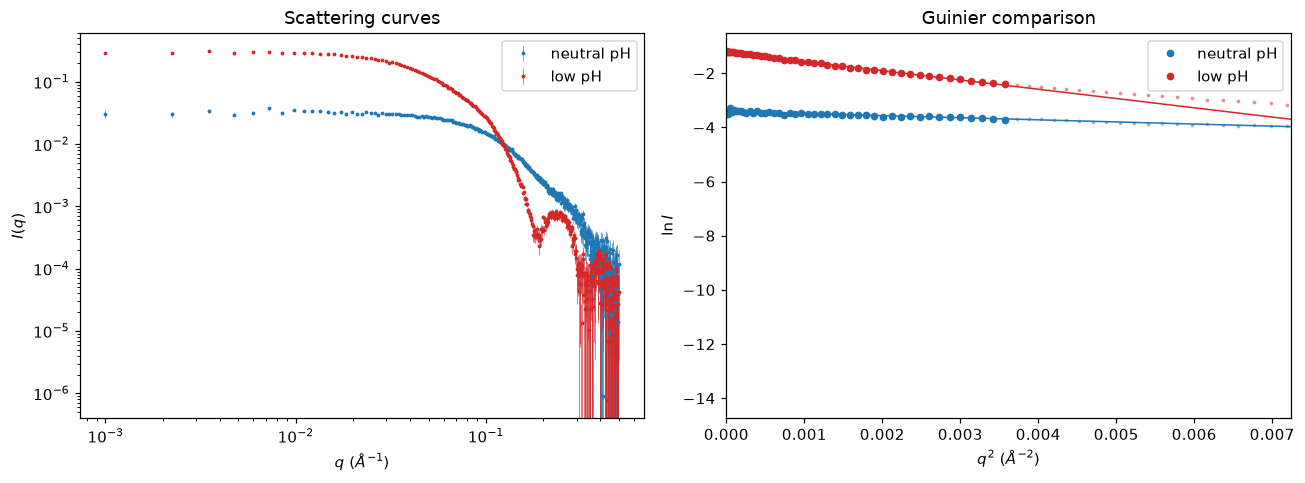

In [11]:
qn, In, dIn = load("SAXS_neutral_pH.dat")
ql, Il, dIl = load("SAXS_low_pH.dat")

print("Neutral pH — choose a Guinier window:")
neut = interactive_guinier(qn, In, dIn, title="Challenge 3: neutral pH",
                           qmin0=float(qn[In > 0][0]), qmax0=0.06)
print("Low pH — choose a Guinier window:")
low = interactive_guinier(ql, Il, dIl, title="Challenge 3: low pH",
                          qmin0=float(ql[Il > 0][0]), qmax0=0.06)

rgn, I0n, maskn = neut["rg"], neut["I0"], neut["mask"]
rgl, I0l, maskl = low["rg"], low["I0"], low["mask"]

fig, (axa, axb) = plt.subplots(1, 2, figsize=(12, 4.5))
axa.errorbar(qn, In, yerr=dIn, fmt=".", ms=3, lw=0.4, color="C0",
             label="neutral pH")
axa.errorbar(ql, Il, yerr=dIl, fmt=".", ms=3, lw=0.4, color="C3",
             label="low pH")
axa.set_xscale("log"); axa.set_yscale("log")
axa.set_xlabel(r"$q\ (\AA^{-1})$"); axa.set_ylabel(r"$I(q)$")
axa.set_title("Scattering curves"); axa.legend()

xr = np.linspace(0, (1.3 / min(rgn, rgl))**2, 50)
for (qq, II, mm, rg, I0, c, lb) in [
        (qn, In, maskn, rgn, I0n, "C0", "neutral"),
        (ql, Il, maskl, rgl, I0l, "C3", "low")]:
    p = II > 0
    axb.plot(qq[p]**2, np.log(II[p]), ".", ms=3, color=c, alpha=0.4)
    axb.plot(qq[mm]**2, np.log(II[mm]), "o", ms=4, color=c, label=f"{lb} pH")
    axb.plot(xr, np.log(I0) - (rg**2 / 3.0) * xr, "-", color=c, lw=1)
axb.set_xlim(0, xr.max()); axb.set_xlabel(r"$q^2\ (\AA^{-2})$")
axb.set_ylabel(r"$\ln I$"); axb.set_title("Guinier comparison"); axb.legend()
plt.tight_layout(); plt.show()


## Summary

**Workflow recap**

1. Load curves with **`sasdata`** (format auto-detected).
2. **Guinier**: choose $q_{\min}$ / $q_{\max}$ with the sliders &rarr; $R_g$, $I(0)$;
   optionally cross-check with the SasView **`guinier`** model.
3. **Kratky** (and dimensionless Kratky) to judge compactness / flexibility.

Use the challenges to practise reading Guinier windows and Kratky shapes —
your notes from those questions are the takeaway, not a filled-in answer key.
